In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster


RAW_PATH = Path(
    "/Users/ilg/Desktop/year4/M4R/python_files/metadata/meta_raw_unnormalised/real_world_bicluster_metrics.csv"
)

OUTPUT_DIR = Path(
    "/Users/ilg/Desktop/year4/M4R/python_files/some_other_eda/real_world_analysis_biclust_only_9"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_CLUSTERS = 5

sns.set_context("notebook")

In [2]:
raw = pd.read_csv(RAW_PATH, dtype=str)

# First row contains metadata names and reducer names
second_header = raw.iloc[0]
data = raw.iloc[1:].reset_index(drop=True)

def remove_pandas_duplicate_suffix(s):
    """
    Removes suffixes like .1, .2 added by pandas when duplicate column names exist.
    """
    return re.sub(r"\.\d+$", "", str(s))

new_cols = []

for col in raw.columns:
    col_str = str(col)
    second = str(second_header[col])

    if col_str.startswith("metadata"):
        # For metadata columns, the first data row contains the real metadata name
        new_cols.append(second)
    else:
        # For statistic columns, combine statistic name and reducer name
        stat_name = remove_pandas_duplicate_suffix(col_str)
        reducer_name = second

        if reducer_name.lower() in {"nan", "none", ""}:
            new_cols.append(stat_name)
        else:
            new_cols.append(f"{stat_name}.{reducer_name}")

data.columns = new_cols

print("Raw rows including header row:", raw.shape[0])
print("Actual real-world datasets:", data.shape[0])
print("Columns after flattening:", data.shape[1])
print(data.columns[:10])

Raw rows including header row: 257
Actual real-world datasets: 256
Columns after flattening: 25
Index(['dataset_id', 'file_path', 'relative_path', 'indices_npz_path',
       'file_type', 'n', 'p',
       '/Users/ilg/Desktop/year4/M4R/python_files/Plaid_metrics/Plaid_metrics.py.PlaidAllMetrics.assumed_k2.self_1',
       '/Users/ilg/Desktop/year4/M4R/python_files/Plaid_metrics/Plaid_metrics.py.PlaidAllMetrics.assumed_k2.self_2',
       '/Users/ilg/Desktop/year4/M4R/python_files/Plaid_metrics/Plaid_metrics.py.PlaidAllMetrics.assumed_k2.self_3'],
      dtype='object')


In [3]:
metadata_cols = [
    "dataset_id",
    "file_path",
    "relative_path",
    "indices_npz_path",
    "file_type",
    "n",
    "p",
]

metadata_cols = [c for c in metadata_cols if c in data.columns]
feature_cols = [c for c in data.columns if c not in metadata_cols]

meta = data[metadata_cols].copy()
X_raw = data[feature_cols].copy()

print("Metadata columns:", metadata_cols)
print("Number of feature columns:", len(feature_cols))

Metadata columns: ['dataset_id', 'file_path', 'relative_path', 'indices_npz_path', 'file_type', 'n', 'p']
Number of feature columns: 18


In [4]:
def parse_numeric_cell(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "" or s.lower() in {"nan", "none", "null"}:
        return np.nan

    # Normalise possible unicode signs
    s = s.replace("−", "-")

    try:
        return float(s)
    except Exception:
        pass

    # Handle strings like '(1.0+0j)', '(inf+0j)'
    try:
        z = complex(s.strip("()"))
        if abs(z.imag) > 1e-8:
            # These statistics should be real; keep real part but warn later if needed.
            return float(z.real)
        return float(z.real)
    except Exception:
        return np.nan


X_num = X_raw.applymap(parse_numeric_cell)

# Convert +/- inf to NaN for QC
X_num = X_num.replace([np.inf, -np.inf], np.nan)

print("Numeric matrix shape:", X_num.shape)
print("Overall missing rate:", X_num.isna().mean().mean())
print("Columns with >50% missing:", (X_num.isna().mean() > 0.5).sum())

Numeric matrix shape: (256, 18)
Overall missing rate: 0.0
Columns with >50% missing: 0


/var/folders/1d/xl5v2cbx13jdwcyb315nmhnc0000gn/T/ipykernel_99113/2720603752.py:29: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_num = X_raw.applymap(parse_numeric_cell)


In [5]:
MAX_MISSING_RATE = 0.05
MIN_STD = 1e-12
MIN_IQR = 1e-12
MAX_RANGE_TO_IQR = 1e6

qc_rows = []
keep_cols = []

for col in X_num.columns:
    x = X_num[col]
    missing_rate = x.isna().mean()

    finite_x = x.dropna()

    if len(finite_x) == 0:
        qc_rows.append({
            "feature": col,
            "keep": False,
            "reason": "all_missing",
            "missing_rate": missing_rate,
        })
        continue

    std = finite_x.std()
    q1 = finite_x.quantile(0.25)
    q3 = finite_x.quantile(0.75)
    iqr = q3 - q1
    value_range = finite_x.max() - finite_x.min()

    if missing_rate > MAX_MISSING_RATE:
        keep = False
        reason = "too_many_missing"
    elif std < MIN_STD:
        keep = False
        reason = "near_zero_std"
    elif iqr < MIN_IQR:
        keep = False
        reason = "near_zero_iqr"
    elif value_range / iqr > MAX_RANGE_TO_IQR:
        keep = False
        reason = "extreme_range_to_iqr"
    else:
        keep = True
        reason = "kept"

    qc_rows.append({
        "feature": col,
        "keep": keep,
        "reason": reason,
        "missing_rate": missing_rate,
        "std": std,
        "iqr": iqr,
        "range": value_range,
        "range_to_iqr": value_range / iqr if iqr > 0 else np.inf,
    })

    if keep:
        keep_cols.append(col)

qc = pd.DataFrame(qc_rows)

X_clean = X_num[keep_cols].copy()

# Median imputation for remaining small missingness
X_clean = X_clean.fillna(X_clean.median(numeric_only=True))

print("Original feature count:", X_num.shape[1])
print("Kept feature count:", X_clean.shape[1])
print("Removed feature count:", X_num.shape[1] - X_clean.shape[1])
print(qc["reason"].value_counts())

qc.to_csv(OUTPUT_DIR / "real_world_feature_qc.csv", index=False)

Original feature count: 18
Kept feature count: 18
Removed feature count: 0
reason
kept    18
Name: count, dtype: int64


In [6]:
def sigmoid_normalise_column(x, eps=1e-12):
    x = pd.Series(x).astype(float)

    med = x.median()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    if abs(iqr) < eps:
        return pd.Series(np.zeros(len(x)), index=x.index)

    scaled = (x - med) / (1.35 * iqr)
    scaled = scaled.clip(lower=-50, upper=50)

    z = 1 / (1 + np.exp(-scaled))
    return pd.Series(z, index=x.index)


X_sigmoid = X_clean.apply(sigmoid_normalise_column, axis=0)

# Save cleaned matrix
real_world_features = pd.concat([meta.reset_index(drop=True), X_sigmoid.reset_index(drop=True)], axis=1)
real_world_features.to_csv(OUTPUT_DIR / "real_world_features_sigmoid_normalised.csv", index=False)

print("Saved normalised real-world feature matrix to:")
print(OUTPUT_DIR / "real_world_features_sigmoid_normalised.csv")

print("Normalised matrix shape:", X_sigmoid.shape)

Saved normalised real-world feature matrix to:
/Users/ilg/Desktop/year4/M4R/python_files/some_other_eda/real_world_analysis_biclust_only_9/real_world_features_sigmoid_normalised.csv
Normalised matrix shape: (256, 18)


In [7]:
def extract_source_name(relative_path):
    if pd.isna(relative_path):
        return "unknown"

    s = str(relative_path)
    parts = s.split("/")

    if len(parts) >= 1:
        return parts[0]

    return "unknown"


if "relative_path" in meta.columns:
    source_name = meta["relative_path"].apply(extract_source_name)
else:
    source_name = meta["dataset_id"].astype(str)

meta_plot = meta.copy()
meta_plot["source_name"] = source_name

print("Number of source datasets:", meta_plot["source_name"].nunique())
print(meta_plot["source_name"].value_counts().head(20))

Number of source datasets: 9
source_name
NIPS_conference_papers_1987_2015                       95
BlogFeedback                                           55
Internet_Advertisement                                 42
Grammatical_Facial_Expressions                         34
Large-scale_Wave_Energy_Farm                           19
SECOM                                                   4
TUANDROMD_Tezpur_University_Android_Malware_Dataset     4
MEx                                                     2
Communities_and_Crime                                   1
Name: count, dtype: int64


In [8]:
Z = linkage(
    X_sigmoid.values,
    method="ward",
    metric="euclidean",
)

cluster_labels = fcluster(Z, t=N_CLUSTERS, criterion="maxclust")

meta_plot["cluster"] = cluster_labels

cluster_output = pd.concat(
    [meta_plot.reset_index(drop=True), X_sigmoid.reset_index(drop=True)],
    axis=1
)

cluster_output.to_csv(
    OUTPUT_DIR / f"real_world_dataset_clusters_k{N_CLUSTERS}.csv",
    index=False,
)

print("Cluster sizes:")
print(meta_plot["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
1    34
2    42
3    99
4    20
5    61
Name: count, dtype: int64


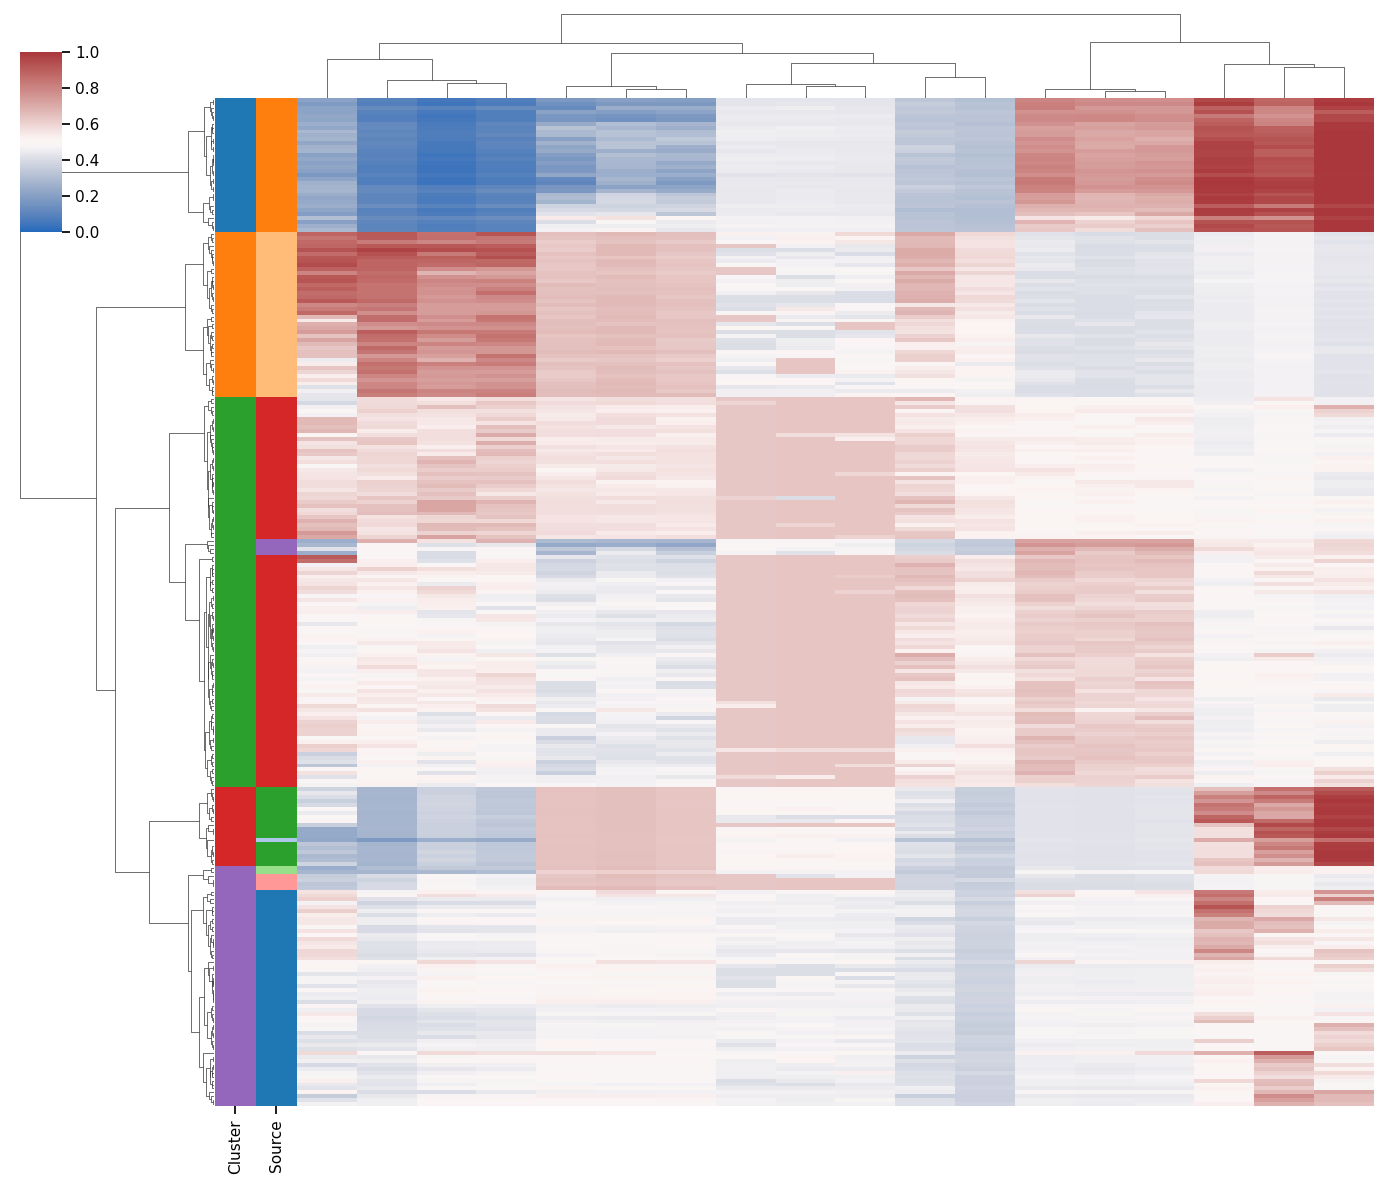

In [9]:
def make_colour_lut(values, palette_name="tab20"):
    values = pd.Series(values).dropna().unique().tolist()
    values = sorted(values, key=lambda x: str(x))
    palette = sns.color_palette(palette_name, n_colors=len(values))
    return dict(zip(values, palette))


# Too many source datasets can make colours unreadable.
# Keep the most common 20 sources and collapse the rest into "Other".
top_sources = meta_plot["source_name"].value_counts().head(20).index

source_for_colour = meta_plot["source_name"].where(
    meta_plot["source_name"].isin(top_sources),
    "Other"
)

cluster_lut = make_colour_lut(meta_plot["cluster"].astype(str), "tab10")
source_lut = make_colour_lut(source_for_colour, "tab20")

row_colors = pd.DataFrame({
    "Cluster": meta_plot["cluster"].astype(str).map(cluster_lut),
    "Source": source_for_colour.map(source_lut),
}, index=X_sigmoid.index)


g = sns.clustermap(
    X_sigmoid,
    row_linkage=Z,
    col_cluster=True,
    row_colors=row_colors,
    cmap="vlag",
    center=0.5,
    vmin=0,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    figsize=(14, 12),
    dendrogram_ratio=(0.15, 0.08),
    colors_ratio=(0.03, 0.03),
    cbar_pos=(0.02, 0.80, 0.03, 0.15),
)

# g.fig.suptitle(
#     "Hierarchical clustering of real-world datasets using PySPoC statistics",
#     y=1.02,
#     fontsize=14,
# )

plt.savefig(
    OUTPUT_DIR / f"real_world_clustermap_k{N_CLUSTERS}.png",
    dpi=250,
    bbox_inches="tight",
)

plt.show()

In [10]:
print("Cluster composition by source dataset:")
source_cluster_tab = pd.crosstab(
    meta_plot["cluster"],
    meta_plot["source_name"],
    normalize="index",
)

display(source_cluster_tab.round(3))

print("Cluster sizes:")
display(meta_plot["cluster"].value_counts().sort_index())

# Average normalised feature profile per cluster
cluster_feature_means = (
    pd.concat([meta_plot["cluster"], X_sigmoid], axis=1)
    .groupby("cluster")
    .mean()
)

cluster_feature_means.to_csv(
    OUTPUT_DIR / f"real_world_cluster_feature_means_k{N_CLUSTERS}.csv"
)

print("Saved cluster summaries to:")
print(OUTPUT_DIR)

Cluster composition by source dataset:


source_name,BlogFeedback,Communities_and_Crime,Grammatical_Facial_Expressions,Internet_Advertisement,Large-scale_Wave_Energy_Farm,MEx,NIPS_conference_papers_1987_2015,SECOM,TUANDROMD_Tezpur_University_Android_Malware_Dataset
cluster,,,,,,,,,
1,0.000,0.00,1.0,0.0,0.00,0.000,0.00,0.000,0.00
2,0.000,0.00,0.0,1.0,0.00,0.000,0.00,0.000,0.00
3,0.000,0.00,0.0,0.0,0.00,0.000,0.96,0.000,0.04
4,0.000,0.05,0.0,0.0,0.95,0.000,0.00,0.000,0.00
5,0.902,0.00,0.0,0.0,0.00,0.033,0.00,0.066,0.00


Cluster sizes:


cluster
1    34
2    42
3    99
4    20
5    61
Name: count, dtype: int64

Saved cluster summaries to:
/Users/ilg/Desktop/year4/M4R/python_files/some_other_eda/real_world_analysis_biclust_only_9
